In [12]:
!pip install sentence-transformers matplotlib seaborn

In [13]:
sentences = [
    # Cricket
    "The batsman scored a century in the match",
    "The bowler delivered a fast yorker",
    "The team won the cricket tournament",
    "The cricket stadium was full of cheering fans",

    # Cooking
    "I cooked pasta with tomato sauce",
    "Baking a cake requires precise measurements",
    "The chef prepared a delicious meal",

    # Cybersecurity
    "Cybersecurity protects systems from attacks",
    "Encryption secures sensitive data",
    "Hackers exploit vulnerabilities in networks",
]

In [14]:
from sentence_transformers import SentenceTransformer

model = SentenceTransformer('all-MiniLM-L6-v2')
embeddings = model.encode(sentences)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


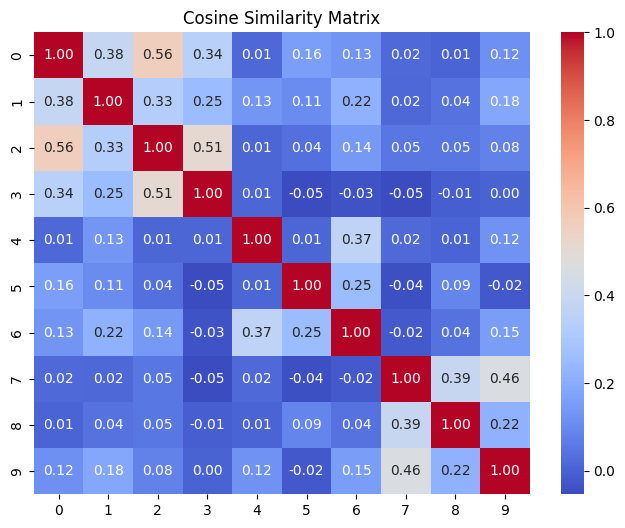

In [15]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import cosine_similarity

similarity_matrix = cosine_similarity(embeddings)

plt.figure(figsize=(8,6))
sns.heatmap(similarity_matrix, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Cosine Similarity Matrix")
plt.show()

In [16]:
query = "The bowler took three wickets in one over"

query_embedding = model.encode([query])
similarities = cosine_similarity(query_embedding, embeddings)[0]

# Get top 2 matches
top_indices = similarities.argsort()[-2:][::-1]

print("Query:", query)
print("\nTop 2 similar sentences:")

for idx in top_indices:
    print(f"\nSentence: {sentences[idx]}")
    print(f"Similarity Score: {similarities[idx]:.4f}")

Query: The bowler took three wickets in one over

Top 2 similar sentences:

Sentence: The batsman scored a century in the match
Similarity Score: 0.5682

Sentence: The bowler delivered a fast yorker
Similarity Score: 0.5414
